                -2.142  -1.071   0.000   1.071   2.142  row_sum
current → next                                                 
-2.142          0.6376  0.2729  0.0753  0.0129  0.0013   1.0000
-1.071          0.1735  0.4000  0.3247  0.0926  0.0092   1.0000
0.000           0.0507  0.2439  0.4108  0.2439  0.0507   1.0000
1.071           0.0092  0.0926  0.3247  0.4000  0.1735   1.0000
2.142           0.0001  0.0020  0.0246  0.1791  0.7941   0.9999
Simulated z_t:
 [-2.14242853 -2.14242853 -2.14242853 ... -1.07121426  0.
  0.        ]


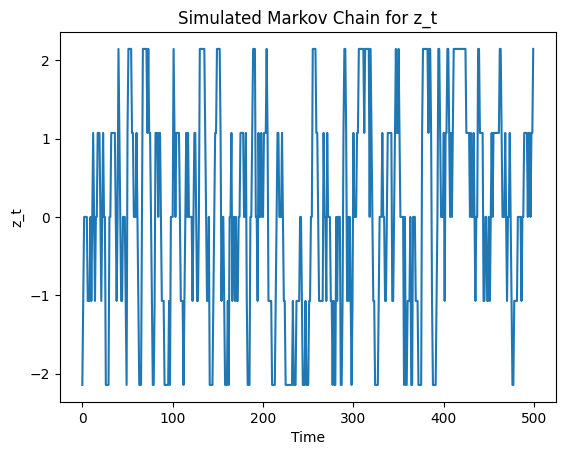

Mean of simulation: 0.28137228008458837
Standard deviation of simulation : 1.4314536807036407
Autocorrelation of simulation (lag 1): 0.7955846620714534
Theoretical Mean: 0
Theoretical Standard Deviation: 0.51
Theoretical Autocorrelation (lag 1): 0.7


In [41]:
import numpy as np
from numpy import sqrt
from scipy.stats import norm
import matplotlib.pyplot as plt
import pandas as pd

# Parameters 
# Ar(1) process z_t+1 = rho*z_t + (1- rho^2) epsilon_t+1 where epsilon ~ N(0,1)
rho = 0.7
m= 3
N = 5
T = 2000 
mean_z = 0
sigma_epsilon = 1
sigma_z = (1-rho**2)

# Tauchen method 
# Creating state space for (slide 28)
Z_N = m * sqrt(sigma_z)
Z_1 = - Z_N
d = (Z_N - Z_1) / (N - 1)
z_grid = np.linspace(Z_1, Z_N, N)

# Transition matrix (slide 29)
P = np.zeros((N, N))
P_i1 = norm.cdf((z_grid[0] - rho * z_grid + d / 2) / sigma_epsilon) # First row
P_iN = 1 - norm.cdf((z_grid[-1] - rho * z_grid + d / 2) / sigma_epsilon) # Last row
P_ij = np.zeros((N-2, N)) # Middle rows 
for i in range(1, N-1):
    for j in range(N):
        P_ij[i-1, j] = norm.cdf((z_grid[j] - rho * z_grid[i] + d / 2) / sigma_epsilon) - norm.cdf((z_grid[j] - rho * z_grid[i] - d / 2) / sigma_epsilon)

P[0, :] = P_i1
P[-1, :] = P_iN
P[1:-1, :] = P_ij

# Create table by using function (see below)
dfP = transition_table(z_grid, P, decimals=4)
print(dfP)

P = P / P.sum(axis=1, keepdims=True) # Normalize rows to sum to 1

# Simulate Markov Chain 
z_sim = np.zeros(T)
z_sim[0] = Z_1  # Start at the lowest state
cdf = np.cumsum(P, axis=1)
cdf[:, -1] = 1.0

z_sim = np.empty(T)
idx = 0  # 0..N-1; e.g., 0 for lowest state
z_sim[0] = z_grid[idx]

u = np.random.rand(T-1)  # in [0,1)
for t in range(1, T):
    idx = np.searchsorted(cdf[idx], u[t-1], side="right")
    z_sim[t] = z_grid[idx]
print("Simulated z_t:\n", z_sim)

# Discard first 500 observations 
z_sim = z_sim[500:]

# Plot the simulated series
plt.plot(z_sim[:500]) #Only first 500 for better visibility
plt.title('Simulated Markov Chain for z_t')
plt.xlabel('Time')
plt.ylabel('z_t')
plt.show()
 
# Compute statistics for the simulated series
mean_z_sim = np.mean(z_sim)
std_z_sim = np.std(z_sim)
autocorr_z_sim = np.corrcoef(z_sim[:-1], z_sim[1:])[0, 1]

print("Mean of simulation:", mean_z_sim)
print("Standard deviation of simulation :", std_z_sim)
print("Autocorrelation of simulation (lag 1):", autocorr_z_sim)

# Theoretical moments (see slide 31)
theoretical_mean = mean_z
theoretical_var = (1-rho**2)**2
theoretical_corr = rho 

print("Theoretical Mean:", theoretical_mean)
print("Theoretical Standard Deviation:", sqrt(theoretical_var))
print("Theoretical Autocorrelation (lag 1):", theoretical_corr)





### Question c

                -1.428  -0.714   0.000   0.714   1.428  row_sum
current → next                                                 
-1.428          0.5220  0.3685  0.0975  0.0115  0.0005   1.0000
-0.714          0.0921  0.5708  0.2850  0.0493  0.0029   1.0001
0.000           0.0163  0.1900  0.5875  0.1900  0.0163   1.0001
0.714           0.0029  0.0493  0.2850  0.5708  0.0921   1.0001
1.428           0.0005  0.0115  0.0975  0.3685  0.5220   1.0000
Simulated z_t (Rouwenhorst):
 [-1.42828569  0.          0.71414284 ... -0.71414284 -1.42828569
 -1.42828569]


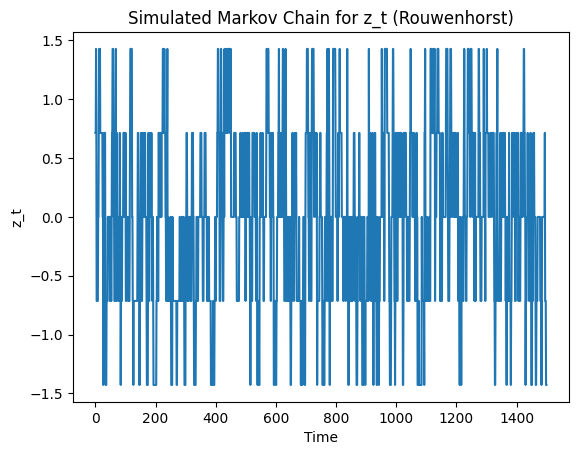

Mean of simulation (Rouwenhorst): -0.02380476142847614
Standard deviation of simulation (Rouwenhorst): 0.7572009860884581
Autocorrelation of simulation (lag 1) (Rouwenhorst): 0.7384013249208888


In [48]:
# Rouwenhorst method 
# here sgima_e =1
std_Z = sqrt(1-rho**2)

# Construct markov chain
def rouwenhorst(N, rho, sigma_epsilon, std_Z):
    p = (1 + rho) / 2 #Becasue zero mean (see slide 38)
    q = p
    s = (1-p) / (2-(p+q))
    psi = sqrt(N-1) * std_Z #See slide 37-39 how to compute
    
    # Initial transition matrix for N=2 #Slide 36
    P = np.array([[p, 1 - p],
                  [1 - q, q]])
    
    # Recursive construction for N>2 #Slide 36
    for n in range(3, N + 1):
        P_new = np.zeros((n, n))
        P_new[:-1, :-1] += p * P
        P_new[:-1, 1:] += (1 - p) * P
        P_new[1:, :-1] += (1 - q) * P
        P_new[1:, 1:] += q * P
        P = P_new / 2
    
    # State space
    z_grid = np.linspace(-psi, psi, N)
    
    return p, s,z_grid, P
 
p, s, z_grid_r, P_r = rouwenhorst(N, rho, sigma_epsilon, std_Z)


# Create table by using function (see below)
dfP = transition_table(z_grid_r, P_r, decimals=4)
print(dfP)

P_r = P_r / P_r.sum(axis=1, keepdims=True) #Nromalize 

# Simulate Markov Chain using Rouwenhorst method
z_sim_r = np.zeros(T)
z_sim_r[0] = Z_1  # Start at the lowest state
cdf_r = np.cumsum(P_r, axis=1)
cdf_r[:, -1] = 1.0
z_sim_r = np.empty(T)
idx = 0

z_sim_r[0] = z_grid_r[idx]
u_r = np.random.rand(T-1)  # in [0,1)
for t in range(1, T):
    idx = np.searchsorted(cdf_r[idx], u_r[t-1], side="right")
    z_sim_r[t] = z_grid_r[idx]
print("Simulated z_t (Rouwenhorst):\n", z_sim_r)

# Discard first 500 observations
z_sim_r = z_sim_r[500:]

# Plot the simulated series
plt.plot(z_sim_r)
plt.title('Simulated Markov Chain for z_t (Rouwenhorst)')
plt.xlabel('Time')
plt.ylabel('z_t')
plt.show()

# Compute statistics for the simulated series
mean_z_sim_r = np.mean(z_sim_r)
std_z_sim_r = np.std(z_sim_r)
autocorr_z_sim_r = np.corrcoef(z_sim_r[:-1], z_sim_r[1:])[0, 1]
print("Mean of simulation (Rouwenhorst):", mean_z_sim_r)
print("Standard deviation of simulation (Rouwenhorst):", std_z_sim_r)
print("Autocorrelation of simulation (lag 1) (Rouwenhorst):", autocorr_z_sim_r)


## Question 2

### Question a

In [61]:
# Strategy: Discredize y and then set z = exp(y) on grid
# Because y still has a symetric distribution but z does not 
sigma_e = 1 
std_Y = sigma_e / sqrt(1-rho**2)
N = 3
rho = 0.7 

# Y has zero mean thus can use function from question 1c
p, s, y_grid_r, P_r = rouwenhorst(N, rho, sigma_epsilon, std_Y)

# Transform to z = exp(y)
z_grid_exp = np.exp(y_grid_r)
print("State space for z = exp(y):", z_grid_exp)

dfP = transition_table(z_grid_exp, P_r, decimals=4)
print(dfP)




State space for z = exp(y): [0.1380285  1.         7.24488053]
                 0.138  1.000   7.245  row_sum
current → next                                
0.138           0.7225  0.255  0.0225      1.0
1.000           0.1275  0.745  0.1275      1.0
7.245           0.0225  0.255  0.7225      1.0


### Question b

In [ ]:
# Solving the Bellman equation 
beta = 0.9
alpha = 0.3
delta = 0.1
k_stst = ((1-beta + beta*delta)/(alpha*beta))**(1/(alpha-1))
c_stst = k_stst**alpha - delta*k_stst


print(k_stst)

k_upper = 1.5 * k_stst
k_lower = 0.5 * k_stst
N_k = 100
k_grid = np.linspace(k_lower, k_upper, N_k)

# Create utility function
def utility(c):
    u = np.full_like(c, -np.inf, dtype=float)
    mask = c > 0
    u[mask] = np.log(c[mask])
    return u

# Create function to create expectation of V(k'z')
# k' is choiche z' is exogenous 
def expected_value(V, P, N):
    EV = np.zeros((len(k_grid), N))
    for iz in range(N):
        EV[:, iz] = P[iz, :].dot(V.T)
    return EV.T

# Value function iteration
Nz = len(z_grid_exp)
Nk = len(k_grid)
V  = np.zeros((Nk, Nz))    
V_new = np.empty_like(V)
pol_kp_idx = np.zeros((Nk, Nz), dtype=int)

for iteration in range(1000):
    print(f"Iteration: {iteration}")
    EV = V @ P.T  # Expected value function

    """" Idea: For each z, we compute the value function over all k and k' pairs and then maximize"""""
    for iz, z in enumerate(z_grid_exp):
        R = z * k_grid**alpha + (1 - delta) * k_grid # Return (Nk*1) vector for current k and z 
        c = R[:, None] - k_grid[None, :]  # Consumption matrix for all (k,k') pairs
        u = utility(c)  # Utility matrix for all (k,k') pairs
        val = u + beta * EV[:, iz][None, :]  # Total value matrix for all (k,k') pairs

        #Maximize 
        best_idx = np.argmax(val, axis=1) # Index of best k' for each k. Picks the row-wise maximum
        V_new[:, iz] = val[np.arange(Nk), best_idx] # fill the iz-th column of V_new
        pol_kp_idx[:, iz] = best_idx
        kprime_policy = k_grid[pol_kp_idx]

    if np.max(np.abs(V_new - V)) < 1e-6:
        break
    V[:] = V_new

# Plot the value function for each z
for iz, z in enumerate(z_grid_exp):
    plt.plot(k_grid, V[:, iz], label=f'z={z:.2f}')
plt.title('Value Function for Different Productivity States')
plt.xlabel('Capital k')
plt.ylabel('Value Function V(k,z)')
plt.legend()

# Plot the policy function for each z
for iz, z in enumerate(z_grid_exp):



1.6520170257619564
Iteration: 0
Iteration: 1
Iteration: 2
Iteration: 3
Iteration: 4
Iteration: 5
Iteration: 6
Iteration: 7
Iteration: 8
Iteration: 9
Iteration: 10
Iteration: 11
Iteration: 12
Iteration: 13
Iteration: 14
Iteration: 15
Iteration: 16
Iteration: 17
Iteration: 18
Iteration: 19
Iteration: 20
Iteration: 21
Iteration: 22
Iteration: 23
Iteration: 24
Iteration: 25
Iteration: 26
Iteration: 27
Iteration: 28
Iteration: 29
Iteration: 30
Iteration: 31
Iteration: 32
Iteration: 33
Iteration: 34
Iteration: 35
Iteration: 36
Iteration: 37
Iteration: 38
Iteration: 39
Iteration: 40
Iteration: 41
Iteration: 42
Iteration: 43
Iteration: 44
Iteration: 45
Iteration: 46
Iteration: 47
Iteration: 48
Iteration: 49
Iteration: 50
Iteration: 51
Iteration: 52
Iteration: 53
Iteration: 54
Iteration: 55
Iteration: 56
Iteration: 57
Iteration: 58
Iteration: 59
Iteration: 60
Iteration: 61
Iteration: 62
Iteration: 63
Iteration: 64
Iteration: 65
Iteration: 66
Iteration: 67
Iteration: 68
Iteration: 69
Iteration: 

# Functions 

In [50]:
def transition_table(z_grid: np.ndarray, P: np.ndarray, decimals: int = 4):
    """Create a pandas DataFrame representing the transition matrix. """
    # ensure 2D float
    P = np.asarray(P, float)
    z = np.asarray(z_grid)

    P = P / P.sum(axis=1, keepdims=True)

    # label rows/cols by state values
    idx = pd.Index([f"{v:.3f}" if np.issubdtype(z.dtype, np.number) else str(v) for v in z],
                   name="current → next")
    cols = pd.Index([f"{v:.3f}" if np.issubdtype(z.dtype, np.number) else str(v) for v in z])

    df = pd.DataFrame(P, index=idx, columns=cols).round(decimals)

    # add a row-sum check
    df["row_sum"] = df.sum(axis=1).round(decimals)
    return df
